# Demo of simulating the random Lotka-Volterra model

The ODE we simulate is
$$
\frac{{\rm d} y_i(t)}{{\rm d}t} =  y_i(t) \left( r_i - \sum_{j=1}^S a_{ij} y_j(t) \right) + m_i
$$
and we want to draw each pair $(a_{ij}, a_{ji})$ (for $i\neq j$) as two ${\rm Normal}(\mu,\sigma)$ random variates with a correlation $\gamma$, and a fixed diagonal $a_{ii}$ (that we typically set to 1).


## Imports

In [1]:
import sys
sys.path.append("../src")

import glv                          # the glv package 
import jax.numpy as jnp             # fast array computations, with numpy-like syntax 
import matplotlib.pyplot as plt
import jax



## Run a single simulation

### Generate parameters

In [2]:
S = 500                 # number of species

# Make the random matrix

mu = 0.5                # mean interaction
sig = 0.3               # std of interaction
gam = 0.                # correlation
diag = 1.               # value on the diagonal; if different between species: diag = jnp.array([a11, a22, ...])
key = None              # no seed; draw on system entropy

A = glv.gaussian_randmat(S, mu, sig, gam, diag, key)

# Other parameters
r = 1.                  # growth rates; if different between species: r = jnp.array([r1, r2, ...])
m = 1e-8                # immigration rate; can also be given as array

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


### Integrate
We use the default method and arguments, which transforms to log-abundance space, and integrates with adaptive step-size Runge-Kutta of order 4/5, using default tolerances.  

In [3]:
N = 1000                # number of samples to record along the trajectory
dT = 1.                 # continuous time interval between sampling
y0 = jnp.ones(S)/S      # initial condition

In [4]:
ts, ys = glv.solve(N, dT, r, A, m, y0)

### Plot the results

The parameters used puts us in the chaotic phase; abundances should fluctuate wildly

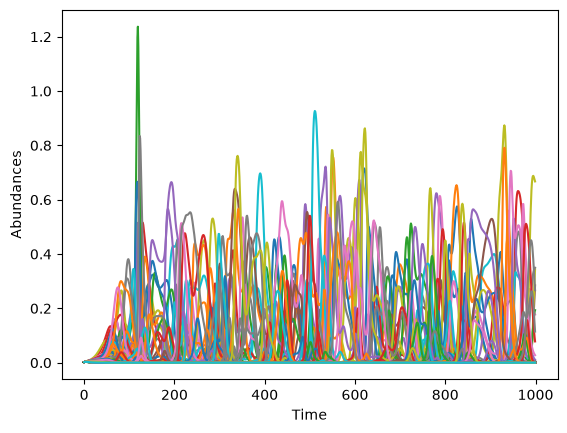

In [5]:
# plot linear abundances

plt.plot(ts, ys)
plt.xlabel("Time")
plt.ylabel("Abundances")
plt.show()

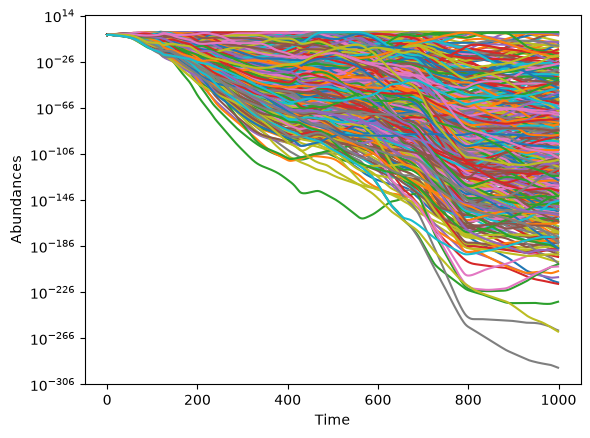

In [10]:
# plot log abundances

plt.plot(ts, ys)
plt.yscale('log')
plt.xlabel("Time")
plt.ylabel("Abundances")
plt.show()

### Notes on solvers and boundary behaviour

The following solvers can be used
- The default `solve` aka `solve_log_RK45` - explicit solver in log-space. Integrating in log-space improves numerical stability/stiffness.
- `solve_RK45` - explicit solver in linear space
- `solve_implicit34`- implicit solver in linear space
- any diffrax adaptive step-size ODE solver can be used; see `make_adaptive_solve`  

If there is positive immigration, there is a limit to how rare a species can become in practise. If there is no immigration, `m=0.`, some species may asymptotically approach 0 abundance, which is problematic:
- Realistically, species should be considered extinct below some small threshold. This prevents unrealistic but mathematically possible recovery from arbitrary low abundance.
- For technical reasons, the best implementation I have found for "extinction" is to freeze abundances once they fall below a `threshold` parameter (by setting the derivative to zero). By default, the solver does not set a threshold. 
- For the log-space solvers (the default), species that crash will eventually cause step sizes to become impractically small. Without immigration `threshold` should always be set
- For linear-space solvers, when species crash machine precision eventually becomes a problem and trajectories look garbled at low abundance, but otherwise not necessarily a problem. Still good to set `threshold` to avoid spurious recovery that's not numerically valid.
- If solvers become very slow, play around with `atol`, `rtol`. If solvers take too many steps there will be an error; then you can increase the `max_steps` argument 

In [ ]:
# Deafult solver with a threshold
# Run this and then rerun the plotting cells above

N = 5000
m = 0.
ts, ys = glv.solve(N, dT, r, A, m, y0, rtol=1e-6, atol=1e-9, threshold=1e-12)

In [ ]:
# Linear-space solver without a threshold
# Run this and then rerun the plotting cells above

N = 5000
m = 0.
ts, ys = glv.solve_RK45(N, dT, r, A, m, y0, rtol=1e-6, atol=1e-9)

In [9]:
# Implicit solver without a threshold
# run this (very slow) and the rerun the plotting cells above
N = 1000
ts, ys = glv.solve_implicit34(N, dT, r, A, m, y0)

## Run a batch of simulations

To run simulations over multiple parameter sets it's much more efficient to vectorize than naively looping. The package makes this efficient and easy.

### Sweep scenario 1
We draw R random matrices from the same statistical ensemble

In [ ]:
R = 10                   # replicates
S = 100
mu = 0.5
sig = 0.3
gam = 0.
diag = 1.
key = 0  

As = glv.gaussian_randmat_ensemble(R, S, mu, sig, gam, diag, key)
rs = jnp.ones(R)
ms = jnp.zeros(R)

### Sweep scenario 2

We have K different sets of statistical parameters, and for each we have R replicates.

Here we will increase μ from 0.2 to 0.8

In [11]:
R = 10                  # replicates
K = 5                   # parameter cases
B = R * K               # batch size
S = 100

ones = jnp.ones(R*K)
mu = jnp.concat([jnp.linspace(0.2, 0.8, K)]*R)
sig = 0.1 * ones
gam = 0. * ones
diag = 1.
seed1 = 1234
seed2 = jax.random.key(1)

As = glv.gaussian_randmat_ensemble(B, S, mu, sig, gam, diag, seed1)

rs = jax.random.uniform(seed2, (B, S), minval=0.5,maxval=1.5)
ms = 1e-6 * ones
y0s = jnp.ones((B,S))/S

### Batch integration (run scenario 1 or 2 first)

In [12]:
N = 100
dT = 1.

ts, ys = glv.jit_batch_solve(N, dT, rs, As, ms, y0s)

Note that the output now has an extra dimension `ys.shape == (B,N,S)` for the batch index.